In [1]:
# 1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as colors
import seaborn as sns
from scipy.stats import normaltest, median_abs_deviation
from sklearn.preprocessing import StandardScaler
import hdbscan
import folium
from folium.plugins import HeatMap


In [2]:
#2
df = pd.read_csv("/Users/fateme/Desktop/term8/پروژه کارشناسی/vesselDataSetFinal.csv")
df['BaseDateTime'] = pd.to_datetime(df['BaseDateTime'])
    

Shape: (304988, 17)
        MMSI        BaseDateTime       LAT        LON   SOG    COG  Heading  \
0  353265000 2020-12-31 12:00:18  27.52875 -115.58843  13.3  143.0      144   
1  353265000 2020-12-31 11:59:27  27.53132 -115.59055  13.4  143.0      145   
2  353265000 2020-12-31 11:58:18  27.53483 -115.59347  13.6  142.0      144   
3  353265000 2020-12-31 11:57:08  27.53828 -115.59638  13.4  143.0      144   
4  353265000 2020-12-31 11:55:48  27.54240 -115.59975  13.5  144.0      144   
5  353265000 2020-12-31 11:54:38  27.54597 -115.60263  13.5  143.0      145   
6  353265000 2020-12-31 11:53:28  27.54942 -115.60555  13.2  143.0      144   
7  353265000 2020-12-31 11:52:18  27.55295 -115.60853  13.3  143.0      144   
8  353265000 2020-12-31 11:51:09  27.55638 -115.61140  13.5  143.0      144   
9  353265000 2020-12-31 11:50:08  27.55943 -115.61392  13.3  143.0      144   

   VesselName         IMO CallSign  VesselType  Status  Length  Width  Draft  \
0  STAR EAGLE  IMO9321938    3

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before opera

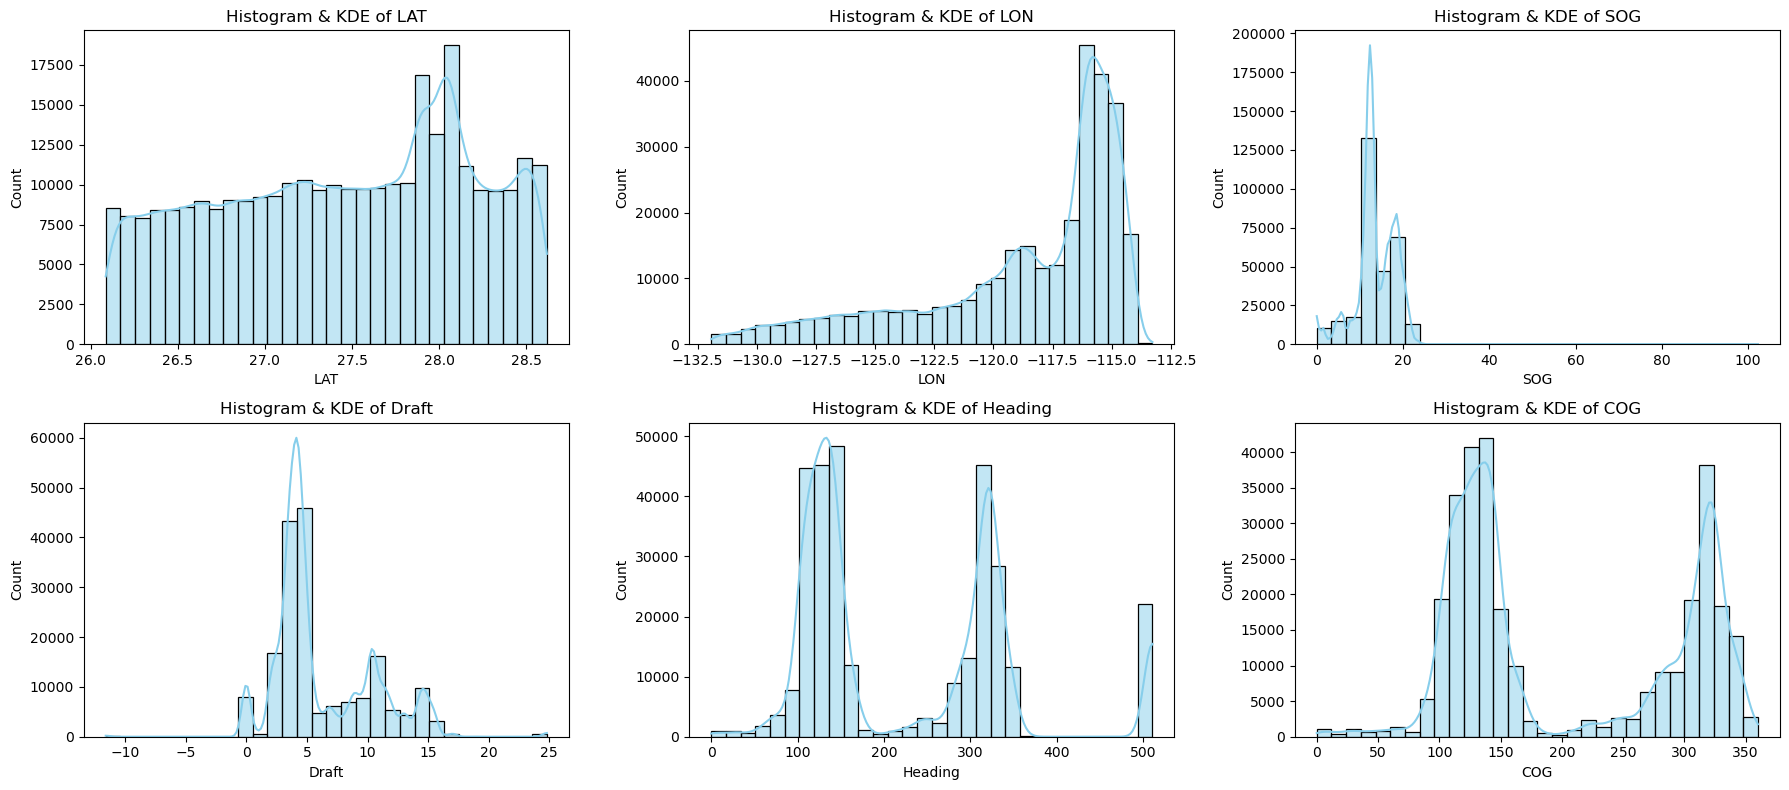

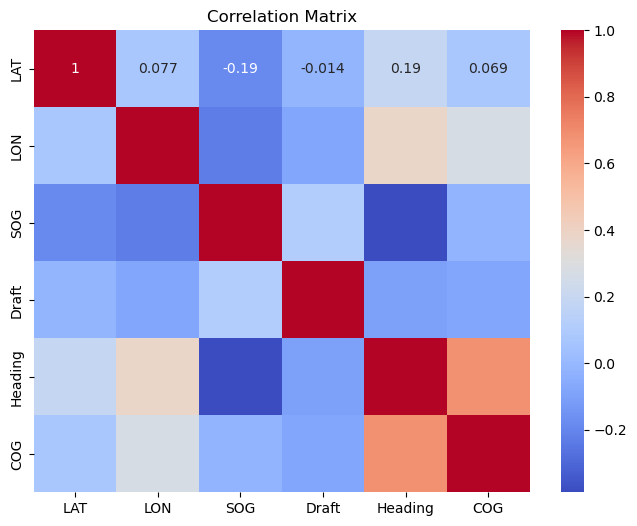

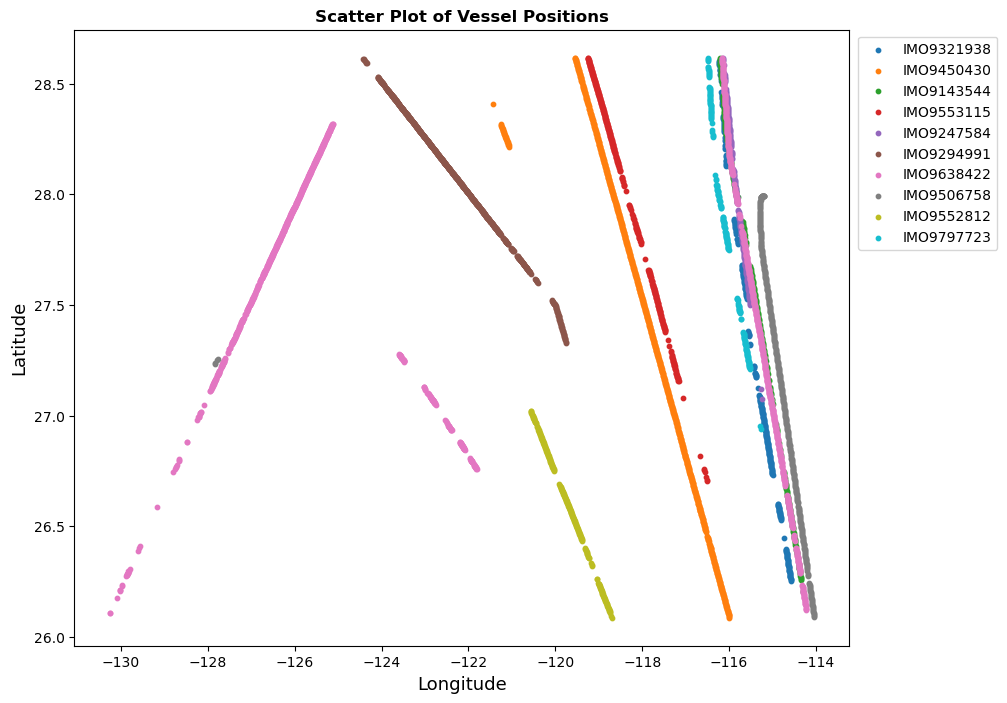

In [3]:
 
#3
#3-1
def perform_eda(df):
    print("Shape:", df.shape)
    print(df.head(10))
    print(df.tail(10))
    print(df.describe())
    print(df.info())
#3-2
    categorial_columns = ['Status', 'VesselType', 'Cargo']
    for col in categorial_columns:
        print(f"Unique values in {col}: {df[col].unique()}")
        print(f"Value counts in {col}:\n{df[col].value_counts()}")
    
    print("Missing values:\n", df.isnull().sum())
    
#3-3
    numeric_cols = ['LAT', 'LON', 'SOG', 'Draft', 'Heading', 'COG']
    fig, axes = plt.subplots(2, 3, figsize=(18, 8))
    axes = axes.flatten()
    for i, col in enumerate(numeric_cols):
        sns.histplot(df[col].dropna(), kde=True, bins=30, color='skyblue', ax=axes[i])
        axes[i].set_title(f"Histogram & KDE of {col}")
    for j in range(len(numeric_cols), len(axes)):
        fig.delaxes(axes[j])
    plt.tight_layout()
    plt.show()

#3-4
    plt.figure(figsize=(8,6))
    sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
    plt.title("Correlation Matrix")
    plt.show()
#3-5
    vessels = df['IMO'].unique()

    plt.figure(figsize=(10, 8))
    for vessel in vessels[:10]:
      data = df[df['IMO'] == vessel]
      plt.scatter(data['LON'], data['LAT'], label=str(vessel), s=10)
      plt.xlabel("Longitude",fontsize=13)
      plt.ylabel("Latitude" ,fontsize=13)
      plt.title("Scatter Plot of Vessel Positions" ,fontweight="bold")
      plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1))
    plt.show()


perform_eda(df)



In [4]:
#4
def map_categorical_names(df):
    cargo_dict = {
        0: "Not available or no cargo",
        30: "Fishing Vessel",
        31: "Towing Vessel",
        32: "Towing Vessel (length > 200m or breadth > 25m)",
        33: "Dredging or underwater ops",
        34: "Diving ops",
        35: "Military ops",
        36: "Sailing Vessel",
        37: "Pleasure Craft",
        40: "High Speed Craft (HSC)",
        50: "Pilot Vessel",
        51: "Search and Rescue Vessel",
        52: "Tug",
        53: "Port Tender",
        54: "Anti-pollution equipment",
        55: "Law Enforcement",
        56: "Spare - Local Vessel",
        57: "Medical Transport",
        58: "Ship’s Tender",
        59: "WIG (Wing In Ground) Craft",
        60: "Chemical Tanker",
        61: "Oil Products Tanker",
        62: "Liquefied Gas Tanker",
        63: "Passenger",
        64: "Passenger/Ro-Ro",
        65: "Cargo",
        66: "Cargo/Ro-Ro",
        67: "Cable Layer",
        68: "No Additional Information",
        69: "No Additional Information",
        70: "Tanker",
        71: "Tanker (hazardous)",
        72: "Tanker (nonhazardous)",
        73: "Tanker (unspecified)",
        74: "Unknown",
        75: "Unknown",
        80: "Tug",
        81: "Tug (offshore)",
        82: "Tug (harbor)",
        90: "Sailing Vessel",
        91: "Pleasure Craft",
        99: "Other"
    }

    vessel_type_dict = {
        70: "Cargo",
        80: "Tanker",
        31: "Fishing ",
        60: "Passenger",
        79: "High Speed Craft",
        71: "Tug",
        90: "Sailing ",
        72: "Other",
        89: "Unknown",
        37: "Pleasure Craft",
        74: "Military ",
        30: "Towing ",
        36: "Dredging or underwater ops"
    }

    status_dict = {
        0:"Under way using engine",
        1:"At anchor",
        2:"Not under command",
        3:"Restricted manoeuverability",
        5:"Moored",
        8:"Reserved for future use",
        15:"Undefined"
    }

    df['CargoName'] = df['Cargo'].map(cargo_dict)
    df['VesselTypeName'] = df['VesselType'].map(vessel_type_dict)
    df['StatusName'] = df['Status'].map(status_dict)
   
    return df

   

In [5]:
df = map_categorical_names(df)

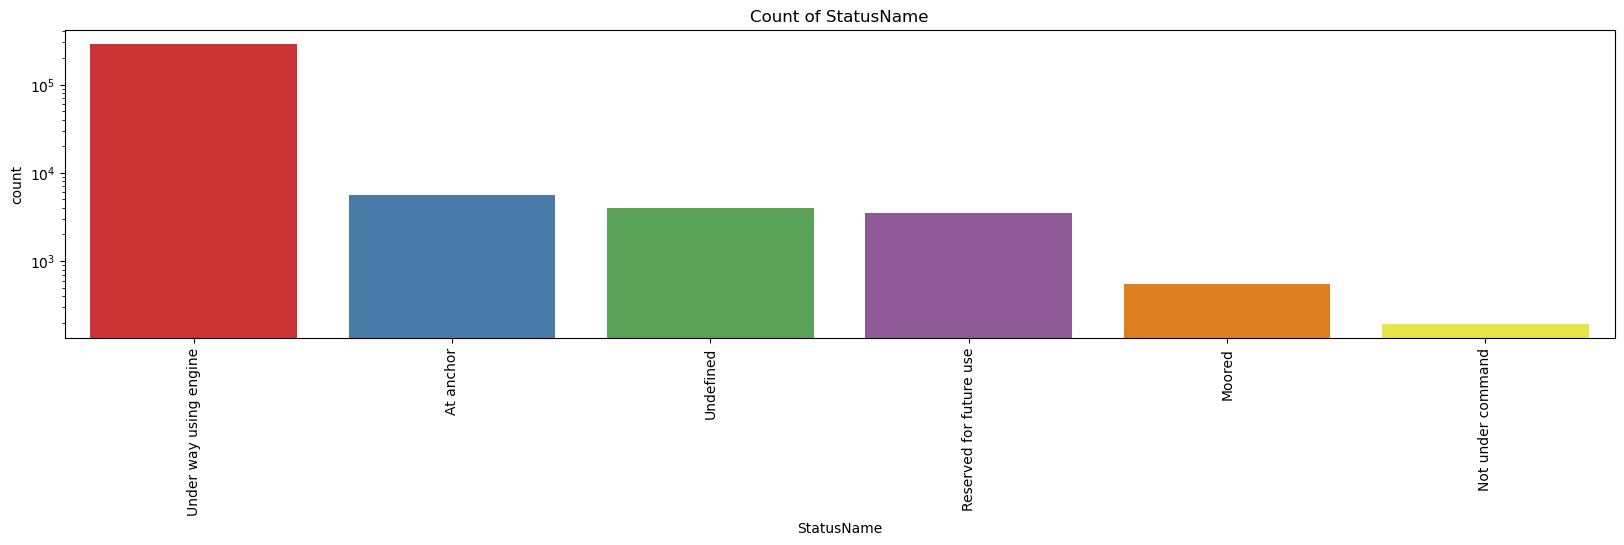

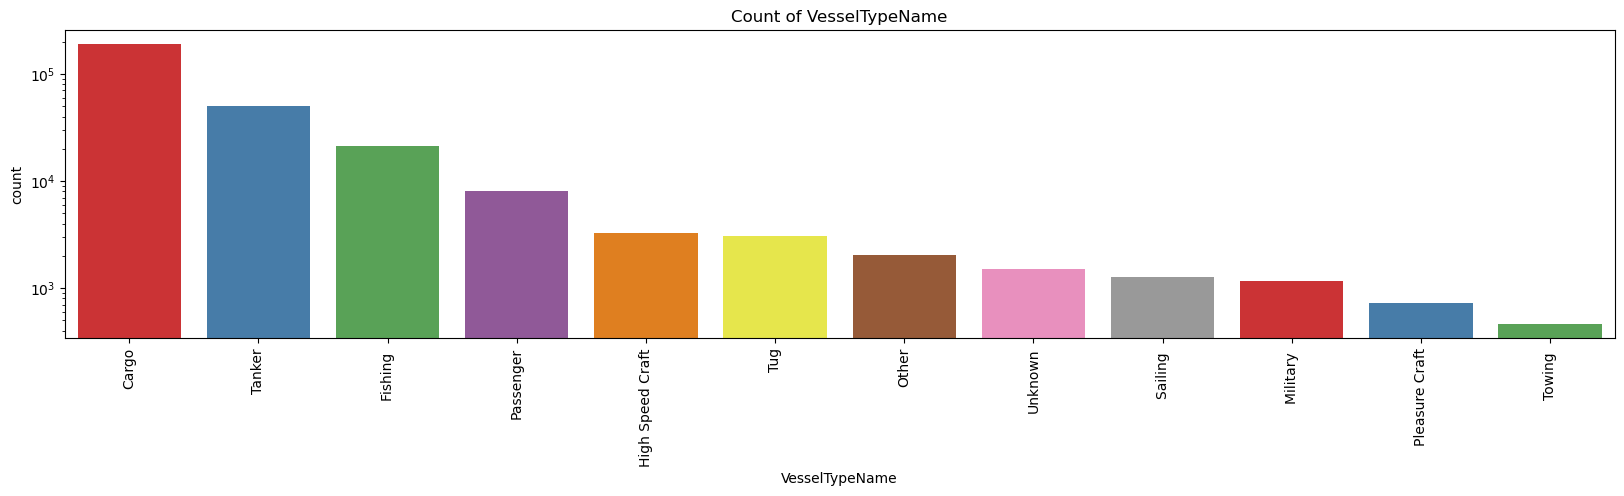

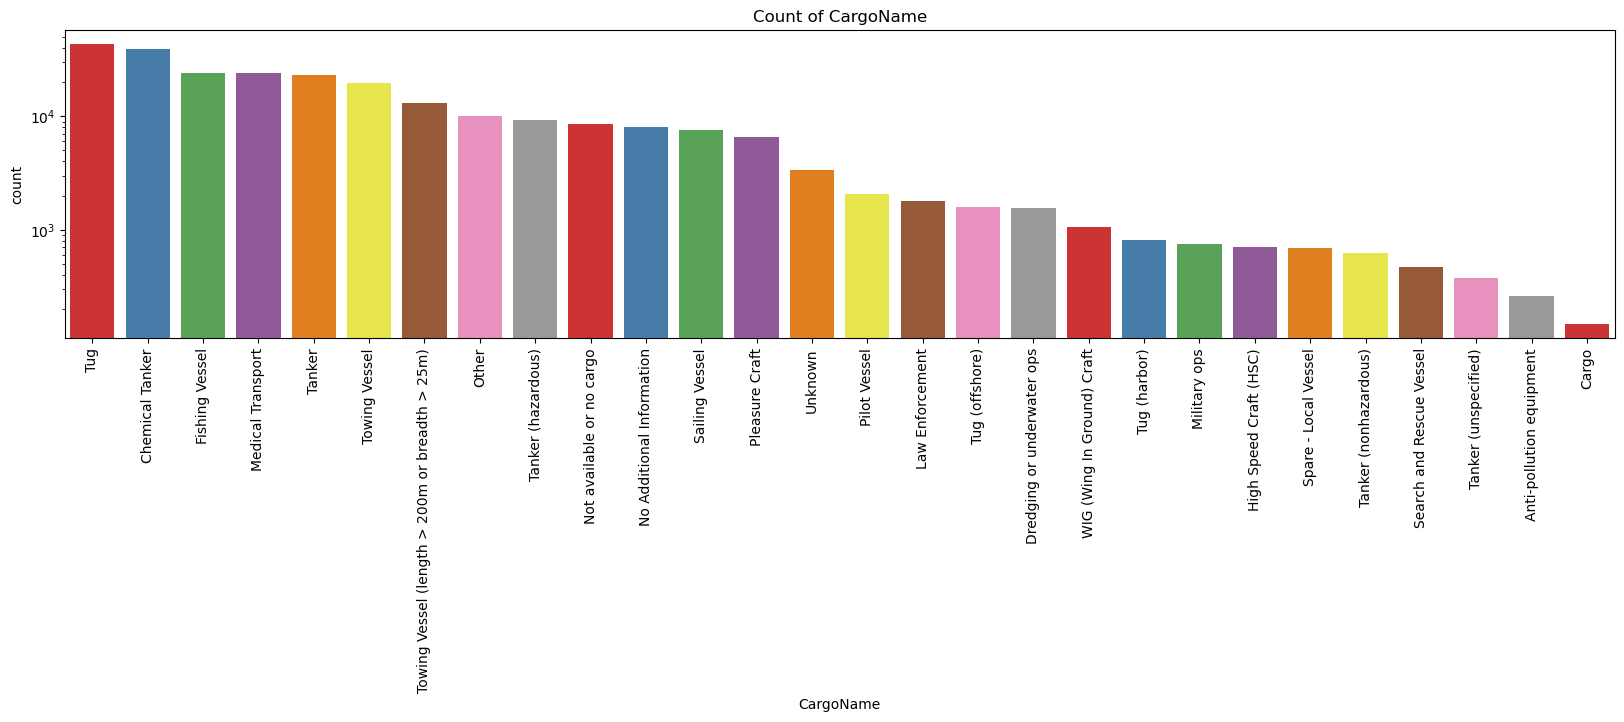

In [6]:
#5
categorical_cols = ['StatusName', 'VesselTypeName', 'CargoName']

for col in categorical_cols:
    plt.figure(figsize=(20, 4))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index, palette='Set1')
    plt.title(f"Count of {col}")
    plt.xticks(rotation=90)
    plt.yscale('log')  
    plt.show()

In [7]:
#6
def clean_data(df):
        
    df = df.drop(columns=['CallSign', 'VesselName', 'MMSI', 'Width', 'Length'], errors='ignore')
    df = df.dropna(subset=['Status'])
    df['VesselType_missing'] = df['VesselType'].isna().astype(int)
    df['VesselType'] = df['VesselType'].fillna(-1)
    df['Draft_missing'] = df['Draft'].isnull().astype(int)
    df['Draft'] = df['Draft'].fillna(-1)
    df['Cargo_is_missing'] = df['Cargo'].isna().astype(int)
    df['Cargo'] = df['Cargo'].fillna(-1)


    
    return df


In [8]:
    
df = clean_data(df)

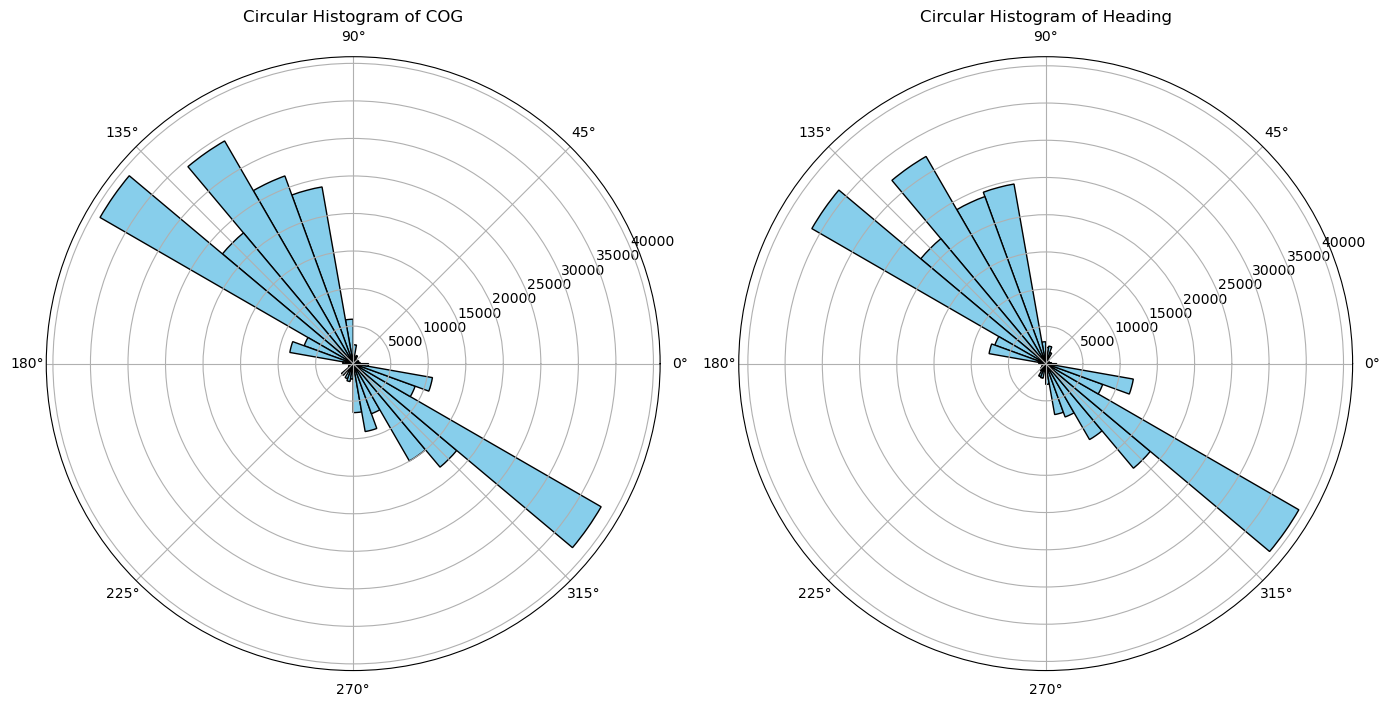

In [9]:
#7
def analyze_angles(df, angle_columns=['COG', 'Heading']):
    fig, axes = plt.subplots(1, len(angle_columns), figsize=(7*len(angle_columns), 7), subplot_kw={'polar': True})
    if len(angle_columns) == 1:
        axes = [axes]
    for i, col in enumerate(angle_columns):
        radians = np.deg2rad(df[col].dropna())
        bins = 36
        counts, bin_edges = np.histogram(radians, bins=bins, range=(0, 2*np.pi))
        widths = np.diff(bin_edges)
        axes[i].bar(bin_edges[:-1], counts, width=widths, bottom=0.0, color='skyblue', edgecolor='black', align='edge')
        axes[i].set_title(f'Circular Histogram of {col}')
    plt.tight_layout()
    plt.show()
analyze_angles(df, angle_columns=['COG', 'Heading'])

In [10]:
#8
 #8-1
def detect_outliers_iqr(df, columns):
    outlier_indices = set()
    
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)].index
        outlier_indices.update(outliers)
        
        print(f"** {col}: {len(outliers)} outliers detected ({len(outliers)/len(df)*100:.2f}%)")
    
    return outlier_indices
 #8-2
def detect_logical_outliers(df):
    logical_outliers = set()
    
    if 'Heading' in df.columns:
        invalid_heading = df[(df['Heading'] < 0) | (df['Heading'] > 360)].index
        logical_outliers.update(invalid_heading)
        print(f"* Heading: {len(invalid_heading)} invalid values detected ({len(invalid_heading)/len(df)*100:.2f}%)")
    
    if 'Draft' in df.columns:
        invalid_draft = df[df['Draft'] < 0].index
        logical_outliers.update(invalid_draft)
        print(f"* Draft: {len(invalid_draft)} negative values detected ({len(invalid_draft)/len(df)*100:.2f}%)")
    
    return logical_outliers
 #8-3
def clean_outliers(df, numerical_cols):
    iqr_outliers = detect_outliers_iqr(df, numerical_cols)
    logic_outliers = detect_logical_outliers(df)
    
    total_outliers = iqr_outliers.union(logic_outliers)
    
    print(f"\n Total rows to remove (union of all outliers): {len(total_outliers)}")
    df_cleaned = df.drop(index=total_outliers).reset_index(drop=True)
    print(f" Final shape after outlier removal: {df_cleaned.shape}")
    
    return df_cleaned


numerical_columns = ['LAT', 'LON', 'SOG', 'Draft', 'Heading']
df = clean_outliers(df, numerical_columns)


** LAT: 0 outliers detected (0.00%)
** LON: 14409 outliers detected (4.73%)
** SOG: 10021 outliers detected (3.29%)
** Draft: 14014 outliers detected (4.60%)
** Heading: 0 outliers detected (0.00%)
* Heading: 21952 invalid values detected (7.20%)
* Draft: 125277 negative values detected (41.10%)

 Total rows to remove (union of all outliers): 162139
 Final shape after outlier removal: (142649, 18)


/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before opera

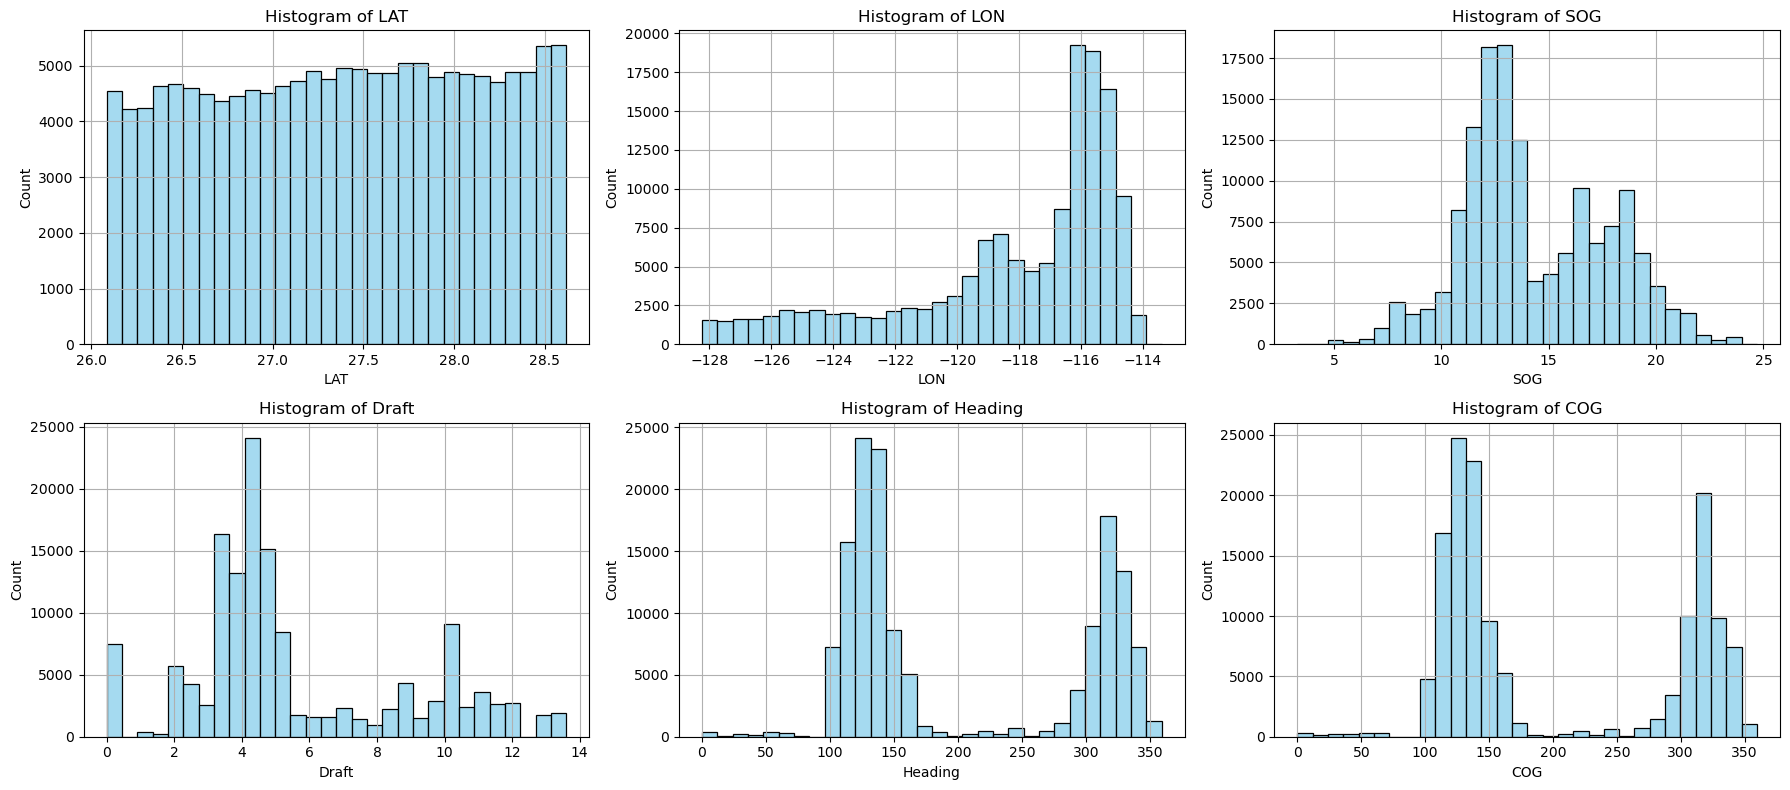

In [11]:
#9
numeric_cols = ['LAT', 'LON', 'SOG', 'Draft', 'Heading', 'COG']

def plot_hist_box(df, numeric_cols):
    fig, axes = plt.subplots(2, 3, figsize=(18, 8))
    axes = axes.flatten()
    for i, col in enumerate(numeric_cols):
        sns.histplot(df[col].dropna(), bins=30, color='skyblue', ax=axes[i])  
        axes[i].set_title(f"Histogram of {col}")
        axes[i].grid(True)
    for j in range(len(numeric_cols), len(axes)):
        fig.delaxes(axes[j])
    plt.tight_layout()
    plt.show()
plot_hist_box(df , numeric_cols)

In [12]:
#10

def perform_hdbscan(df, min_cluster_size=10):
    stopped_df = df[df['SOG'] < 5].copy()
    coords = stopped_df[['LAT', 'LON']].dropna()
    scaler = StandardScaler()
    coords_scaled = scaler.fit_transform(coords)
    clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size)
    cluster_labels = clusterer.fit_predict(coords_scaled)
    stopped_df.loc[coords.index, 'cluster'] = cluster_labels
    print("Cluster counts:")
    print(stopped_df['cluster'].value_counts())
    poi_df = stopped_df[stopped_df['cluster'] == -1]
    print(f"Number of suspicious POIs: {len(poi_df)}")
    return stopped_df, poi_df





In [14]:
#11

def create_folium_heatmap(stopped_df, filename='heatmap_clusters.html'):
    clustered_points = stopped_df[stopped_df['cluster'] != -1]
    m = folium.Map(location=[clustered_points['LAT'].mean(), clustered_points['LON'].mean()], zoom_start=6)
    heat_data = list(zip(clustered_points['LAT'], clustered_points['LON']))
    HeatMap(heat_data, radius=8, blur=5).add_to(m)
    m.save(filename)
    print(f"Map saved as {filename}")

stopped_df, poi_df = perform_hdbscan(df, min_cluster_size=10)
create_folium_heatmap(stopped_df)


Cluster counts:
cluster
 1.0    32
 0.0    13
-1.0    10
Name: count, dtype: int64
Number of suspicious POIs: 10
Map saved as heatmap_clusters.html


In [16]:
#12

def create_cluster_map(stopped_df, filename='cluster_map.html'):
    all_points = stopped_df.dropna(subset=['LAT', 'LON'])
    m = folium.Map(location=[all_points['LAT'].mean(), all_points['LON'].mean()], zoom_start=6)
    unique_clusters = sorted(c for c in all_points['cluster'].unique() if c != -1)
    colormap = cm.get_cmap('tab20', len(unique_clusters))  
    norm = colors.Normalize(vmin=0, vmax=len(unique_clusters) - 1)

    for _, row in all_points.iterrows():
        cluster = row['cluster']
        if cluster == -1:
            color = 'black'  
        else:
            color = colors.to_hex(colormap(norm(unique_clusters.index(cluster))))

        folium.CircleMarker(
            location=[row['LAT'], row['LON']],
            radius=3,
            color=color,
            fill=True,
            fill_opacity=0.7,
            popup=f"Cluster: {cluster}"
        ).add_to(m)

   
    m.save(filename)
    print(f"Map saved as {filename}")

create_cluster_map(stopped_df)


Map saved as cluster_map.html


/var/folders/sm/cpyswzqs2sqctgyxf7sq342h0000gn/T/ipykernel_16516/4257262133.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colormap = cm.get_cmap('tab20', len(unique_clusters))


In [17]:
#13
poi_vessels = df[df['IMO'].isin(poi_df['IMO'])]
print(poi_vessels['CargoName'].value_counts())
print(poi_vessels['VesselTypeName'].value_counts())


CargoName
Tug (offshore)    1120
Fishing Vessel    1027
Name: count, dtype: int64
VesselTypeName
Cargo    2147
Name: count, dtype: int64


/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


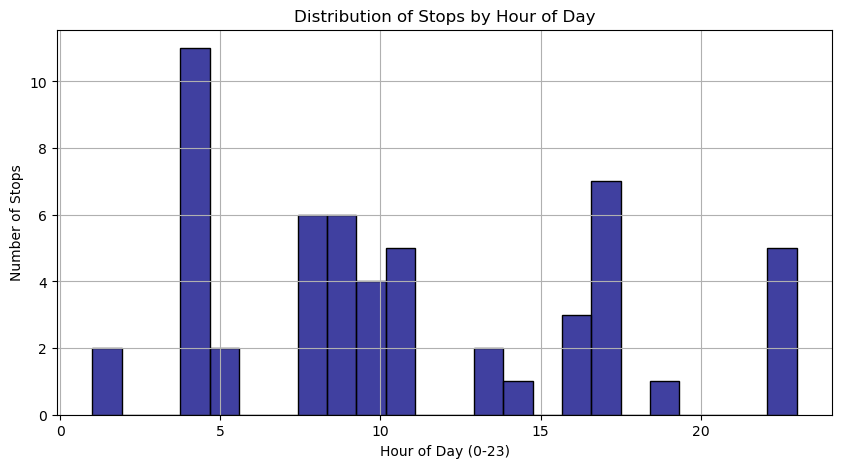

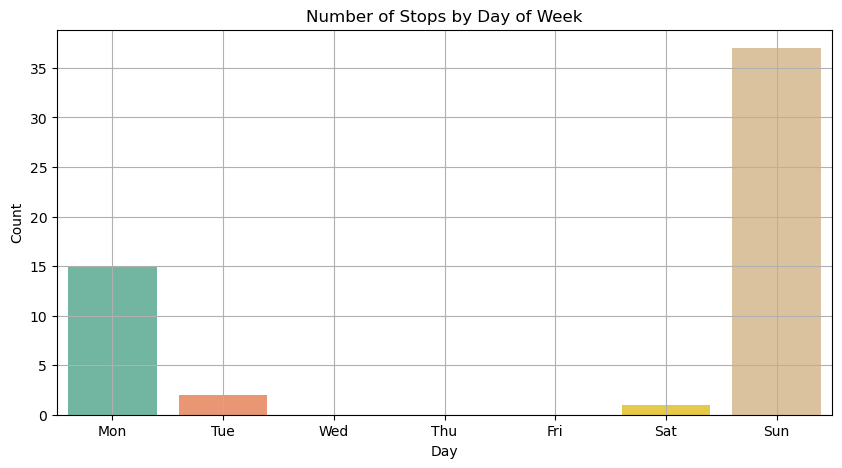

In [18]:
#14
  #14-1
def plot_temporal_distributions(stopped_df):
    stopped_df = stopped_df.copy() 
    stopped_df['hour'] = stopped_df['BaseDateTime'].dt.hour
    stopped_df['month'] = stopped_df['BaseDateTime'].dt.month
    stopped_df['dayofweek'] = stopped_df['BaseDateTime'].dt.dayofweek
    day_map = {0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu', 4: 'Fri', 5: 'Sat', 6: 'Sun'}
    stopped_df['day_name'] = stopped_df['dayofweek'].map(day_map)
  #14-2

    plt.figure(figsize=(10, 5))
    sns.histplot(stopped_df['hour'], bins=24, kde=False, color='navy')
    plt.title('Distribution of Stops by Hour of Day')
    plt.xlabel('Hour of Day (0-23)')
    plt.ylabel('Number of Stops')
    plt.grid(True)
    plt.show()

  #14-3
    plt.figure(figsize=(10, 5))
    sns.countplot(x='day_name', data=stopped_df, order=['Mon','Tue','Wed','Thu','Fri','Sat','Sun'], palette='Set2')
    plt.title("Number of Stops by Day of Week")
    plt.xlabel("Day")
    plt.ylabel("Count")
    plt.grid(True)
    plt.show()

plot_temporal_distributions(stopped_df)

